# Практическая работа №2 "Создание конкуртной нейронной сети"

**Цель работы:** изучить топологию и алгоритм функционирования конкурентной нейронной сети.












Практическая работа №2

по дисциплине

Нейросетевые системы



Выполнил: студент группы АТ-24д

Рогалев Глеб Иванович

Проверил:

Михайлов И. С.




In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

np.random.seed(42)

# ============================================
# 1. Исходные образы 6x6 (Вариант 29: *, /, +, =, #)
# ============================================

star = np.array([
    [0, 0, 1, 0, 0, 0],
    [1, 0, 1, 0, 1, 0],
    [0, 1, 1, 1, 0, 0],
    [0, 0, 1, 0, 0, 0],
    [0, 1, 0, 1, 0, 0],
    [1, 0, 0, 0, 1, 0]
], dtype=float)

slash = np.array([
    [0, 0, 0, 0, 1, 0],
    [0, 0, 0, 1, 1, 0],
    [0, 0, 0, 1, 0, 0],
    [0, 0, 1, 1, 0, 0],
    [0, 1, 1, 0, 0, 0],
    [0, 1, 0, 0, 0, 0]
], dtype=float)

plus = np.array([
    [0, 0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 0],
    [0, 0, 1, 0, 0, 0],
    [1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0],
    [0, 0, 1, 0, 0, 0]
], dtype=float)

equally = np.array([
    [0, 0, 0, 0, 0, 0],
    [1, 1, 1, 1, 1, 1],
    [0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0],
    [1, 1, 1, 1, 1, 1],
    [0, 0, 0, 0, 0, 0]
], dtype=float)

grid = np.array([
    [0, 0, 0, 1, 0, 1],
    [0, 0, 0, 1, 0, 1],
    [1, 1, 1, 1, 1, 1],
    [0, 0, 1, 0, 1, 0],
    [1, 1, 1, 1, 1, 1],
    [0, 1, 0, 1, 0, 0]
], dtype=float)

base_images = {
    "*": star,
    "/": slash,
    "+": plus,
    "=": equally,
    "#": grid
}

In [ ]:
# ============================================
# 2. Вспомогательные функции
# ============================================

def to_vector(img):
    return img.T.reshape(-1).astype(float)

def normalize_vector(x):
    norm = np.linalg.norm(x)
    return x / norm if norm != 0 else x

def add_noise(img, flips):
    noisy = img.copy().reshape(-1)
    idx = np.random.choice(len(noisy), size=flips, replace=False)
    noisy[idx] = 1 - noisy[idx]
    return noisy.reshape(img.shape)

def show_images(images_dict, title):
    fig, axes = plt.subplots(1, len(images_dict), figsize=(14, 3))
    fig.suptitle(title, fontsize=14)
    for ax, (name, img) in zip(axes, images_dict.items()):
        ax.imshow(img, cmap="gray_r")
        ax.set_title(name)
        ax.axis("off")
    plt.show()

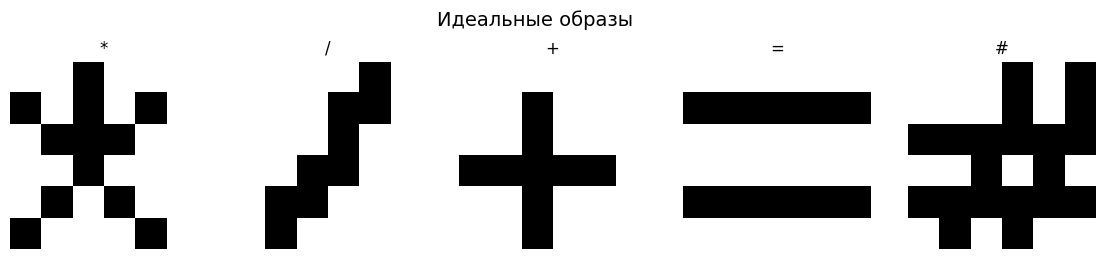

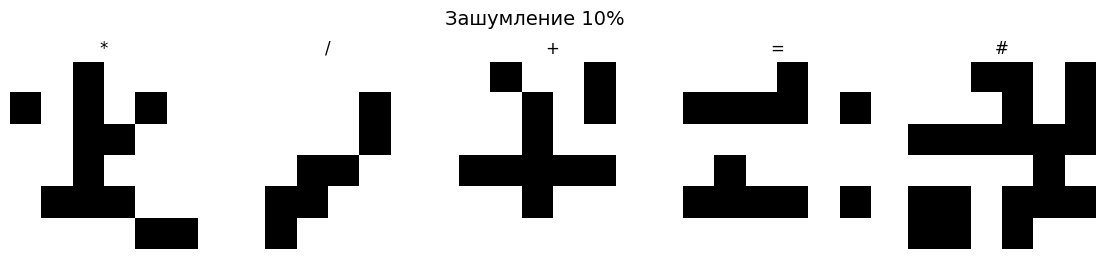

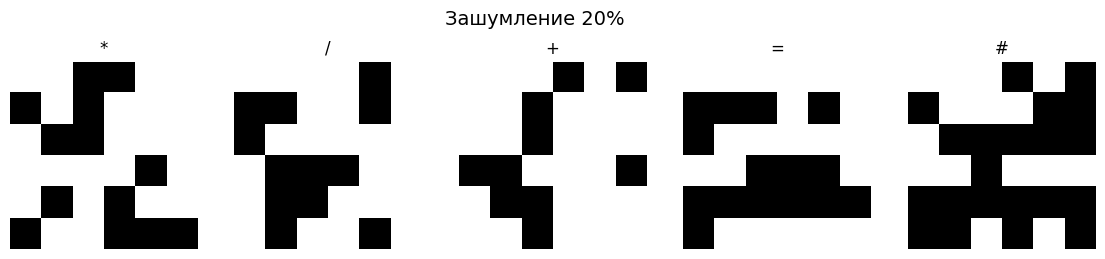

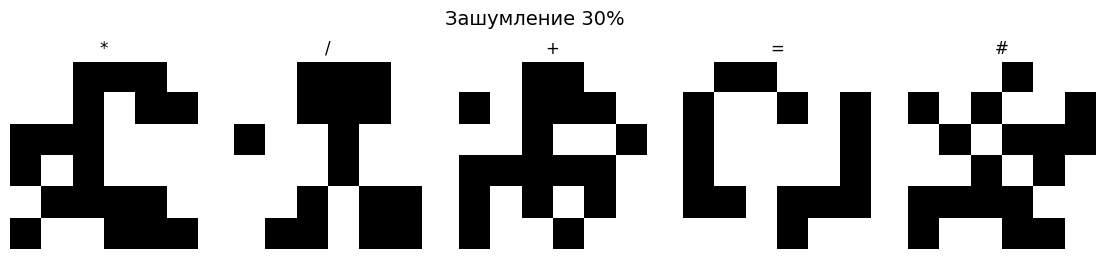

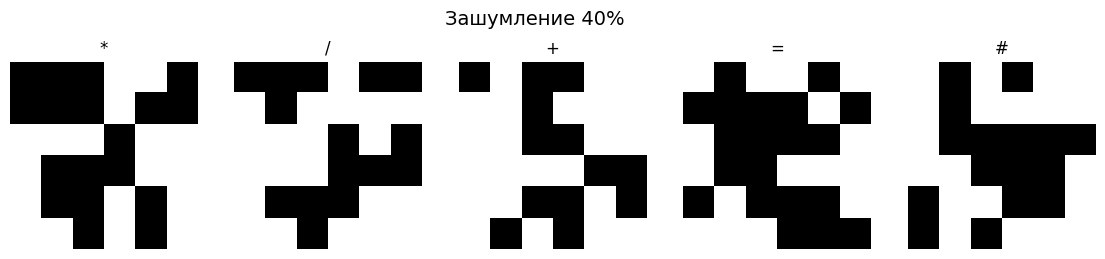

In [ ]:
# ============================================
# 3. Создание зашумленных образов
# ============================================

noise_levels = {
    "0%": 0,
    "10%": 4,
    "20%": 7,
    "30%": 11,
    "40%": 14
}

all_images = {}
for noise_name, flips in noise_levels.items():
    all_images[noise_name] = {}
    for label, img in base_images.items():
        if flips == 0:
            all_images[noise_name][label] = img.copy()
        else:
            all_images[noise_name][label] = add_noise(img, flips)

show_images(base_images, "Идеальные образы")
show_images(all_images["10%"], "Зашумление 10%")
show_images(all_images["20%"], "Зашумление 20%")
show_images(all_images["30%"], "Зашумление 30%")
show_images(all_images["40%"], "Зашумление 40%")

In [ ]:
# ============================================
# 4. Подготовка обучающей выборки
# ============================================

train_labels = list(base_images.keys())
X_train = np.array([normalize_vector(to_vector(base_images[label])) for label in train_labels])

# ============================================
# 5. Обучение конкурентной сети
# ============================================

def train_competitive_network(X, m=5, h=0.05, epochs=30, seed=42):
    np.random.seed(seed)
    n = X.shape[1]
    W = np.random.rand(n, m) * 2 - 1

    for j in range(m):
        W[:, j] = normalize_vector(W[:, j])

    f = np.ones(m)

    for _ in range(epochs):
        for x in X:
            krit = [0.0 for _ in range(m)]

            # Вычисление критерия (расстояние * частота побед)
            for j in range(m):
                s = 0.0
                for i in range(n):
                    s += (x[i] - W[i][j]) ** 2
                krit[j] = math.sqrt(s) * f[j]

            # Поиск нейрона-победителя
            winner = 0
            min_value = krit[0]
            for j in range(1, m):
                if krit[j] < min_value:
                    min_value = krit[j]
                    winner = j

            # Увеличение счетчика побед
            f[winner] += 1

            # Коррекция весов нейрона-победител
            for i in range(n):
                W[i][winner] = W[i][winner] + h * (x[i] - W[i][winner])

    return W, f

In [ ]:
# ============================================
# 6. Классификация образов
# ============================================

def predict_cluster(x, W, f):
    x = normalize_vector(x)
    # Вычисление критерия
    krit = np.array([np.linalg.norm(x - W[:, j]) * f[j] for j in range(W.shape[1])])
    return np.argmin(krit) + 1

def evaluate_network(all_images, W, f):
    labels = ["*", "/", "+", "=", "#"]
    levels = ["0%", "10%", "20%", "30%", "40%"]
    result = np.zeros((5, 5), dtype=int)

    for i, label in enumerate(labels):
        for j, level in enumerate(levels):
            x = to_vector(all_images[level][label])
            result[i, j] = predict_cluster(x, W, f)

    return result

In [ ]:
# ============================================
# 7. Эксперимент 1: m = 5
# ============================================

print("Обучение сети (m=5)...")
W5, f5 = train_competitive_network(X_train, m=5, h=0.05, epochs=30, seed=42)
REZ5 = evaluate_network(all_images, W5, f5)

print("\nРезультат для m = 5")
print("Строки: *, /, +, =, #")
print("Столбцы: 0%, 10%, 20%, 30%, 40%")
print(REZ5)

Обучение сети (m=5)...

Результат для m = 5
Строки: *, /, +, =, #
Столбцы: 0%, 10%, 20%, 30%, 40%
[[3 3 3 3 3]
 [2 2 2 2 4]
 [1 1 1 1 4]
 [5 5 5 4 4]
 [4 4 4 4 4]]


In [ ]:
# ============================================
# 8. Эксперимент 2: m = 3
# ============================================

print("\nОбучение сети (m=3)...")
W3, f3 = train_competitive_network(X_train, m=3, h=0.05, epochs=30, seed=42)
REZ3 = evaluate_network(all_images, W3, f3)

print("\nРезультат для m = 3")
print("Строки: *, /, +, =, #")
print("Столбцы: 0%, 10%, 20%, 30%, 40%")
print(REZ3)


Обучение сети (m=3)...

Результат для m = 3
Строки: *, /, +, =, #
Столбцы: 0%, 10%, 20%, 30%, 40%
[[2 1 1 1 1]
 [3 1 1 1 1]
 [1 1 1 1 1]
 [3 1 1 1 1]
 [2 2 2 2 1]]


In [ ]:
# ============================================
# 9. Эксперимент 3: m = 4
# ============================================

print("\nОбучение сети (m=4)...")
W3, f3 = train_competitive_network(X_train, m=4, h=0.05, epochs=30, seed=42)
REZ3 = evaluate_network(all_images, W3, f3)

print("\nРезультат для m = 4")
print("Строки: *, /, +, =, #")
print("Столбцы: 0%, 10%, 20%, 30%, 40%")
print(REZ3)


Обучение сети (m=4)...

Результат для m = 4
Строки: A, C, E, F, H
Столбцы: 0%, 10%, 20%, 30%, 40%
[[1 1 1 1 1]
 [2 3 1 1 3]
 [3 3 3 3 1]
 [4 4 4 4 1]
 [2 1 1 1 1]]


In [ ]:
# ============================================
# 8. Эксперимент 4: m = 3, h = 0.01
# ============================================

print("\nОбучение сети (m=3)...")
W3, f3 = train_competitive_network(X_train, m=3, h=0.01, epochs=30, seed=42)
REZ3 = evaluate_network(all_images, W3, f3)

print("\nРезультат для m = 3")
print("Строки: *, /, +, =, #")
print("Столбцы: 0%, 10%, 20%, 30%, 40%")
print(REZ3)


Обучение сети (m=3)...

Результат для m = 3
Строки: A, C, E, F, H
Столбцы: 0%, 10%, 20%, 30%, 40%
[[2 3 2 2 3]
 [3 3 3 3 3]
 [1 1 3 1 3]
 [3 1 3 3 3]
 [2 2 2 1 1]]


In [ ]:
# ============================================
# 8. Эксперимент 5: h = 0.01, m = 4
# ============================================

print("\nОбучение сети (m=4)...")
W3, f3 = train_competitive_network(X_train, m=4, h=0.01, epochs=30, seed=42)
REZ3 = evaluate_network(all_images, W3, f3)

print("\nРезультат для m = 4")
print("Строки: *, /, +, =, #")
print("Столбцы: 0%, 10%, 20%, 30%, 40%")
print(REZ3)


Обучение сети (m=4)...

Результат для m = 4
Строки: A, C, E, F, H
Столбцы: 0%, 10%, 20%, 30%, 40%
[[1 1 3 1 3]
 [1 3 3 1 3]
 [3 3 3 3 3]
 [4 4 4 4 1]
 [2 2 2 3 3]]


In [ ]:
# ============================================
# 8. Эксперимент 6: m = 5, h = 0.1
# ============================================

print("\nОбучение сети (m=5)...")
W3, f3 = train_competitive_network(X_train, m=5, h=0.1, epochs=30, seed=42)
REZ3 = evaluate_network(all_images, W3, f3)

print("\nРезультат для m = 5")
print("Строки: *, /, +, =, #")
print("Столбцы: 0%, 10%, 20%, 30%, 40%")
print(REZ3)


Обучение сети (m=5)...

Результат для m = 5
Строки: A, C, E, F, H
Столбцы: 0%, 10%, 20%, 30%, 40%
[[3 3 3 3 3]
 [2 2 2 2 2]
 [1 1 1 1 4]
 [5 5 5 5 4]
 [4 4 4 4 4]]


**Вывод:**
1. Чем больше m, тем тоньше разделение образов, но выше риск переобучения
2. Чем меньше m, тем сильнее обобщение, но ниже детализация распознования


**Малое h**: веса изменяются плавно, сеть устойчива, но может не успеть обучиться за фиксированное число эпох


**Среднее h**: быстрая адаптация без потери стабильности, наилучшие результаты при шуме до 30%

**Большое h**: веса сильно меняются на каждом шаге, сеть быстро адаптируется, но становится чувствительной к шуму и выбросам

**Выводы:**


1.   В чём заключается смысл самообучения нейронной сети?
**Самообучение** - это процесс, при котором нейроная сеть адаптируется к входным данным, выявляя внутренние зависимости и закономерности без использованиея размеченных данных и учителя


2. Как выполняется обучение конкурентной нейронной сети?

Обучение происходит по следующему алгоритму:
* Инициализация весов: векторы весов каждого нейрона инициализируются случайными значениями и нормируются.
* Подача входного вектора: на вход сети подаётся нормированный вектор .
* Вычисление критерия для каждого нейрона :
где — число побед нейрона (фактор «совести»).
* Определение победителя: нейрон с минимальным значением становится победителем.
* Коррекция весов победителя по правилу Кохонена:
где — скорость обучения.
* Обновление счётчика побед:
* Повторение шагов 2–6 для всех образцов в течение нескольких эпох до стабилизации кластеризации.
3. Каким образом определяется нейрон-победитель в конкурентной нейронной сети?

При обучении сети определяется **нейрон-победитель**, для которого значение $y_j$ максимально. После этого веса нейрона-победителя корректируются по правилу:

$w_{ij}(t+1) = w_{ij}(t) + \beta \bigl(x_i - w_{ij}(t)\bigr)$

где $\beta$ — скорость обучения.

Смысл данного правила состоит в том, что вектор весов нейрона-победителя приближается к входному вектору. Это позволяет нейрону лучше распознавать похожие образы при последующих подачах входных данных.

4. Где используются самоорганизующиеся нейронные сети?
* Кластеризация данных
* Выделение признаков
* Сжатие представленных данных

5. Каковы основные достоинства и недостатки конкурентной нейронной сети?
 * **Достоинства**
 - Обучение без учителя
 - Устойчивость к шуму
 - Данные легко визуализировать и анализирвоать

* **Минусы**
-Случайная инициализация
- Нейроны могут никогда не стать победителями
- Фиксированное число кластеров


